In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
# connect to the local SQLite database
conn = sqlite3.connect(r"c:\Users\akand\Downloads\MIG_Cement_Records.db")
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print(tables)

# Load tables into DataFrames
operations = pd.read_sql_query("SELECT * FROM Operations", conn)
sites = pd.read_sql_query("SELECT * FROM Sites", conn)
cement = pd.read_sql_query("SELECT * FROM CementTypes", conn)

# Close connection
conn.close()

[('Sites',), ('CementTypes',), ('Operations',)]


In [8]:
# ============================================================
# 1. LOAD ALL TABLES SAFELY, THEN CLOSE CONNECTION
# ============================================================

conn = sqlite3.connect(r"C:\Users\akand\Downloads\MIG_Cement_Records.db")
cursor = conn.cursor()

tables = ["Operations", "Sites", "CementTypes"]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table} row count:", cursor.fetchone()[0])

operations = pd.read_sql_query("SELECT * FROM Operations", conn)
sites = pd.read_sql_query("SELECT * FROM Sites", conn)
cement = pd.read_sql_query("SELECT * FROM CementTypes", conn)

conn.close()   # SAFE — all cleaning happens in pandas now

Operations row count: 32880
Sites row count: 30
CementTypes row count: 3


In [9]:
# ============================================================
# 2. BASIC STRUCTURAL INFORMATION - 
# (DISSHT) - Describe, Info, Shape, Sample, Head, Tail
# (NUDCD)- Nulls, Unique values, Duplicates, Columns, Dtypes 
# ============================================================

def preview_df(df, table):
    """Professional preview of a dataframe."""
    print(f"\n{'='*60}")
    print(f"[table] {table.upper()}")
    print(f"{'='*60}")

    print("\n[DESCRIBE]")
    print(df.describe())

    print("\n[INFO]")
    print(df.info())

    print("\n[SHAPE]")
    print(df.shape)
    print("\n")

    print("\n[SAMPLE]")
    print(df.sample())

    print("\n[HEAD]")
    print(df.head())

    print("\n[TAIL]")
    print(df.tail())

    print("\n[NULL VALUES]")
    print(df.isna().sum())
    
    print("\n[UNIQUE VALUES]")
    print(df.nunique())

    print("\n[DUPLICATES]")
    print(df.duplicated().sum())

    print("\n[COLUMNS]")
    print(df.columns)

    print("\n[DTYPES]")
    print(df.dtypes)



In [10]:
# Call the function
preview_df(operations, "operations")
preview_df(sites, "sites")
preview_df(cement, "cement")


[table] OPERATIONS

[DESCRIBE]
       planned_pour_tonnes  consumed_tonnes  opening_inventory_tonnes  \
count         32880.000000     32880.000000              32880.000000   
mean             30.697158        23.720475               3066.682205   
std              19.493713        16.846251               5586.029168   
min               0.000000         0.000000                  0.000000   
25%              12.830000        10.710000                  1.280000   
50%              33.455000        19.720000                 50.710000   
75%              47.612500        36.492500               3298.522500   
max              69.980000        69.970000              20646.180000   

       deliveries_tonnes  closing_inventory_tonnes       rain_mm  \
count       32880.000000              32880.000000  32880.000000   
mean           29.293009               3072.254739      5.008120   
std            12.325600               5593.015910      4.997142   
min             0.000000              

In [4]:
# ============================================================
# 3. CONVERT DATE COLUMN
# ============================================================

operations['date'] = pd.to_datetime(operations['date'], errors='coerce')

In [5]:
# ============================================================
# 4. STANDARDISE IDs (site_id, cement_type)
# ============================================================

def clean_id(series):
    return (
        series.astype(str)
              .str.strip()
              .str.upper()
    )

operations['site_id'] = clean_id(operations['site_id'])
operations['cement_type'] = clean_id(operations['cement_type'])

sites['site_id'] = clean_id(sites['site_id'])
cement['cement_type'] = clean_id(cement['cement_type'])

In [6]:
# ============================================================
# 5. check for spelling errors, trailing spaces,
# weird characters, and inconsistent casing.
# ============================================================

def check_categorical(df, col):
    print(f"\n{'='*60}")
    print(f"Checking column: {col}")
    print(f"{'='*60}")

    # Raw unique values
    print("\n[RAW UNIQUE VALUES]")
    print(df[col].unique())

    # Strip whitespace
    stripped = df[col].astype(str).str.strip()
    print("\n[STRIPPED UNIQUE VALUES]")
    print(stripped.unique())

    # Uppercase
    upper = stripped.str.upper()
    print("\n[UPPERCASE UNIQUE VALUES]")
    print(upper.unique())

    # Compare raw vs cleaned
    mismatches = df[col][upper != df[col]]
    print("\n[MISMATCHED VALUES (raw vs cleaned)]")
    print(mismatches.head())

    # Check for hidden characters
    weird = df[col].astype(str).apply(lambda x: repr(x))
    print("\n[VALUES WITH HIDDEN CHARACTERS]")
    print(weird.head())

    print("\nDone.")


In [7]:
# Run checks on all categorical columns
# Operations
check_categorical(operations, "site_id")
check_categorical(operations, "cement_type")

# Sites
check_categorical(sites, "site_id")
check_categorical(sites, "region")
check_categorical(sites, "behavior")

# CementTypes
check_categorical(cement, "cement_type")



Checking column: site_id

[RAW UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SITE_021' 'SITE_022' 'SITE_023' 'SITE_024'
 'SITE_025' 'SITE_026' 'SITE_027' 'SITE_028' 'SITE_029' 'SITE_030']

[STRIPPED UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SITE_021' 'SITE_022' 'SITE_023' 'SITE_024'
 'SITE_025' 'SITE_026' 'SITE_027' 'SITE_028' 'SITE_029' 'SITE_030']

[UPPERCASE UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SIT

In [8]:
# ============================================================
# 6. VALIDATE JOIN KEYS — SITE IDs
# ============================================================

missing_sites = set(operations['site_id']) - set(sites['site_id'])
print("\nMissing site_ids (Operations → Sites):", missing_sites)

if len(missing_sites) == 0:
    print("✔ All site_ids in Operations exist in Sites.")
else:
    print("⚠ Some site_ids do not exist in Sites — investigate before merging.")



Missing site_ids (Operations → Sites): set()
✔ All site_ids in Operations exist in Sites.


In [9]:
# ============================================================
# 7. VALIDATE JOIN KEYS — CEMENT TYPES
# ============================================================

missing_cement = set(operations['cement_type']) - set(cement['cement_type'])
print("\nMissing cement_types (Operations → CementTypes):", missing_cement)

if len(missing_cement) == 0:
    print("✔ All cement_types in Operations exist in CementTypes.")
else:
    print("⚠ Some cement_types do not exist in CementTypes — investigate before merging.")


Missing cement_types (Operations → CementTypes): set()
✔ All cement_types in Operations exist in CementTypes.


In [12]:
# ============================================================
# 8. VALIDATE INVENTORY LOGIC
# ============================================================

operations['expected_closing'] = (
    operations['opening_inventory_tonnes'] +
    operations['deliveries_tonnes'] -
    operations['consumed_tonnes']
)

operations['inventory_match'] = (
    operations['expected_closing'].round(2) ==
    operations['closing_inventory_tonnes'].round(2)
)

inventory_issues = operations[operations['inventory_match'] == False]

print("\nInventory mismatches:", len(inventory_issues))

if len(inventory_issues) == 0:
    print("✔ Inventory logic is consistent across all rows.")
else:
    print("⚠ Inventory mismatches detected — review these rows.")
    print(inventory_issues[['date','site_id','cement_type',
                            'opening_inventory_tonnes','deliveries_tonnes',
                            'consumed_tonnes','closing_inventory_tonnes',
                            'expected_closing']].head())


Inventory mismatches: 7
⚠ Inventory mismatches detected — review these rows.
            date   site_id cement_type  opening_inventory_tonnes  \
1096  2022-01-01  SITE_002       CEM_I                     28.46   
13152 2022-01-01  SITE_013     CEM_III                     24.44   
15344 2022-01-01  SITE_015       CEM_I                     26.95   
25208 2022-01-01  SITE_024      CEM_II                     73.23   
28496 2022-01-01  SITE_027      CEM_II                     62.79   

       deliveries_tonnes  consumed_tonnes  closing_inventory_tonnes  \
1096               12.12            15.70                     24.87   
13152              25.63            50.08                      0.00   
15344              18.36             9.46                     35.86   
25208              36.61            64.29                     45.56   
28496              13.10            12.38                     63.52   

       expected_closing  
1096              24.88  
13152             -0.01  
15344   

In [11]:
##fixing the inventory mismatch. 
# In real construction data, mismatches happen because:
# A delivery was recorded late
# A pour was recorded on the wrong day
# A weighbridge malfunctioned
# Someone typed the wrong number
# Inventory was manually adjusted
# A delivery was missed or duplicated


In [13]:
# Recalculate expected closing
operations['expected_closing'] = (
    operations['opening_inventory_tonnes'] +
    operations['deliveries_tonnes'] -
    operations['consumed_tonnes']
)

# Compare using tolerance
operations['inventory_match'] = np.isclose(
    operations['expected_closing'],
    operations['closing_inventory_tonnes'],
    atol=0.01
)

# Fix mismatches
operations.loc[~operations['inventory_match'], 'closing_inventory_tonnes'] = \
    operations.loc[~operations['inventory_match'], 'expected_closing']

# Recompute match
operations['inventory_match'] = np.isclose(
    operations['expected_closing'],
    operations['closing_inventory_tonnes'],
    atol=0.01
)

# Count mismatches
print("Remaining mismatches:", (~operations['inventory_match']).sum())


Remaining mismatches: 0


In [14]:
# merge the tables using left join site_id 
#merge the tables using left join cement_type
merged = operations.merge(sites, on="site_id", how="left")
merged = merged.merge(cement, on="cement_type", how="left")

In [15]:
# identify redundant columns - duplicates or unnnecessary columns (those with only one unique value)
redundant_columns = [col for col in merged.columns if merged[col].nunique() == 1]
print("Redundant columns:", redundant_columns)

Redundant columns: ['inventory_match']


In [16]:
# drop redundant columns - inventory_match.
merged = merged.drop(columns=["inventory_match"])


In [17]:
# Check for duplicates in the merged DataFrame
# duplicates = merged[merged.duplicated()]
merged.columns


Index(['date', 'site_id', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'silo_capacity_x',
       'expected_closing', 'region', 'silo_capacity_y', 'behavior'],
      dtype='object')

### EDA - EXPLORATORY DATA ANALYSIS


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [19]:
df = merged.copy()
df.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity_x,expected_closing,region,silo_capacity_y,behavior
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,63.85,North,448,aggressive
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,38.56,North,448,aggressive
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,47.06,North,448,aggressive
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,32.64,North,448,aggressive
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,0.00,North,448,aggressive


###### NOTE Tosin - Silo_capacity_x is from the first table (Operations) 
###### and Silo_capacity_y is from the second table (CementTypes). 
###### You might want to rename them for clarity.


In [20]:
# Renaming columns - silo_capacity_x and silo_capacity_y for clarity and consistency.
# Remove the duplicate silo capacity column from operations
merged = merged.drop(columns=["silo_capacity_x"])

# Rename the silo capacity column from sites
merged = merged.rename(columns={"silo_capacity_y": "silo_capacity"})


In [21]:
# ============================================================
# EDA 1. BASIC STRUCTURAL INFORMATION  
# (DISSHT) - Describe, Info, Shape, Sample, Head, Tail
# (NUDCD)- Nulls, Unique values, Duplicates, Columns, Dtypes 
# ============================================================

def preview_df(df, name):
    """Professional preview of a dataframe."""
    print(f"\n{'='*60}")
    print(f"[TABLE] {name.upper()}")
    print(f"{'='*60}")

    print("\n[DESCRIBE]")
    print(df.describe())

    print("\n[INFO]")
    print(df.info())

    print("\n[SHAPE]")
    print(df.shape)

    print("\n[SAMPLE]")
    print(df.sample())

    print("\n[HEAD]")
    print(df.head())

    print("\n[TAIL]")
    print(df.tail())

    print("\n[NULL VALUES]")
    print(df.isna().sum())
    
    print("\n[UNIQUE VALUES]")
    print(df.nunique())

    print("\n[DUPLICATES]")
    print(df.duplicated().sum())

    print("\n[COLUMNS]")
    print(df.columns)

    print("\n[DTYPES]")
    print(df.dtypes)


In [22]:
preview_df(df, "cleaned merged dataset")


[TABLE] CLEANED MERGED DATASET

[DESCRIBE]
                                date  planned_pour_tonnes  consumed_tonnes  \
count                          32880         32880.000000     32880.000000   
mean   2023-07-02 12:00:00.000000256            30.697158        23.720475   
min              2022-01-01 00:00:00             0.000000         0.000000   
25%              2022-10-01 18:00:00            12.830000        10.710000   
50%              2023-07-02 12:00:00            33.455000        19.720000   
75%              2024-04-01 06:00:00            47.612500        36.492500   
max              2024-12-31 00:00:00            69.980000        69.970000   
std                              NaN            19.493713        16.846251   

       opening_inventory_tonnes  deliveries_tonnes  closing_inventory_tonnes  \
count              32880.000000       32880.000000              32880.000000   
mean                3066.682205          29.293009               3072.254739   
min          

In [23]:
# quick check 
merged.columns

Index(['date', 'site_id', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'expected_closing',
       'region', 'silo_capacity', 'behavior'],
      dtype='object')

##### TIME SERIES ANALYSIS EDA

The graph/code below is meant to check for seasonality, trends, cyclicity, spikes and quiet periods.  

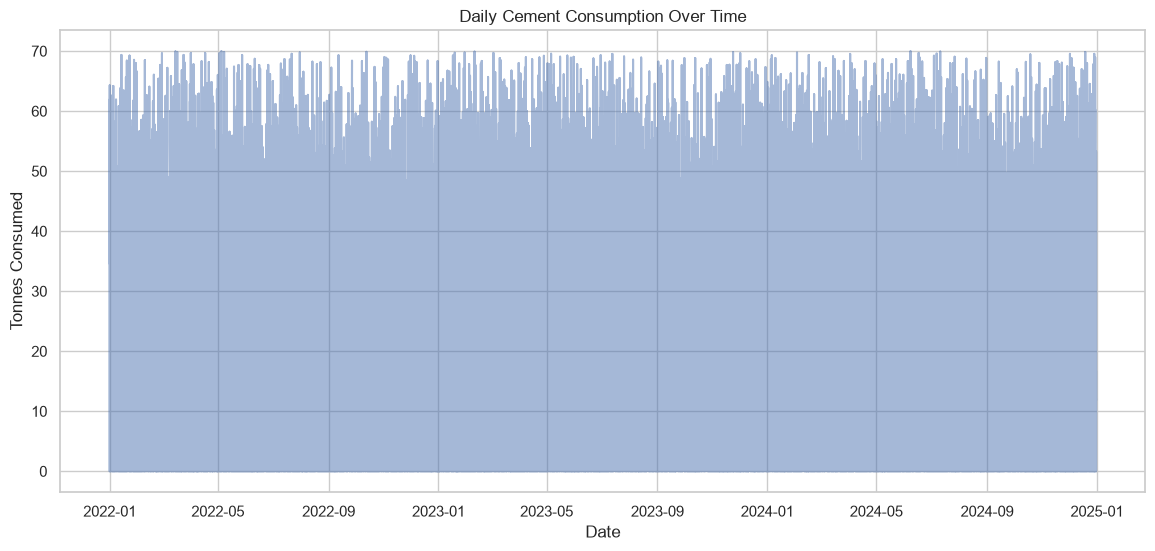

In [24]:
# 1. Start fresh
df = merged.copy()

# 2. Make sure date is a column
df = df.reset_index(drop=True)

# 3. Sort by date
df = df.sort_values("date")

# 4. Set date as index for time‑series work
df = df.set_index("date")

# 5. Plot using df.index
plt.figure(figsize=(14,6))
plt.plot(df.index, df['consumed_tonnes'], alpha=0.5)
plt.title("Daily Cement Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Tonnes Consumed")
plt.show()


##### Insight:There is noise in the daily pattern. 

In [ ]:
df.columns

Index(['site_id', 'cement_type', 'planned_pour_tonnes', 'consumed_tonnes',
       'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'expected_closing',
       'region', 'silo_capacity', 'behavior'],
      dtype='object')

####### = - Note Tosin, u had to change the date coloumn into the index so as to be able to play around with the dataset. 

### Monthly Cement Consumption.

C:\Users\akand\AppData\Local\Temp\ipykernel_24784\3190044662.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['consumed_tonnes'].resample('M').sum()


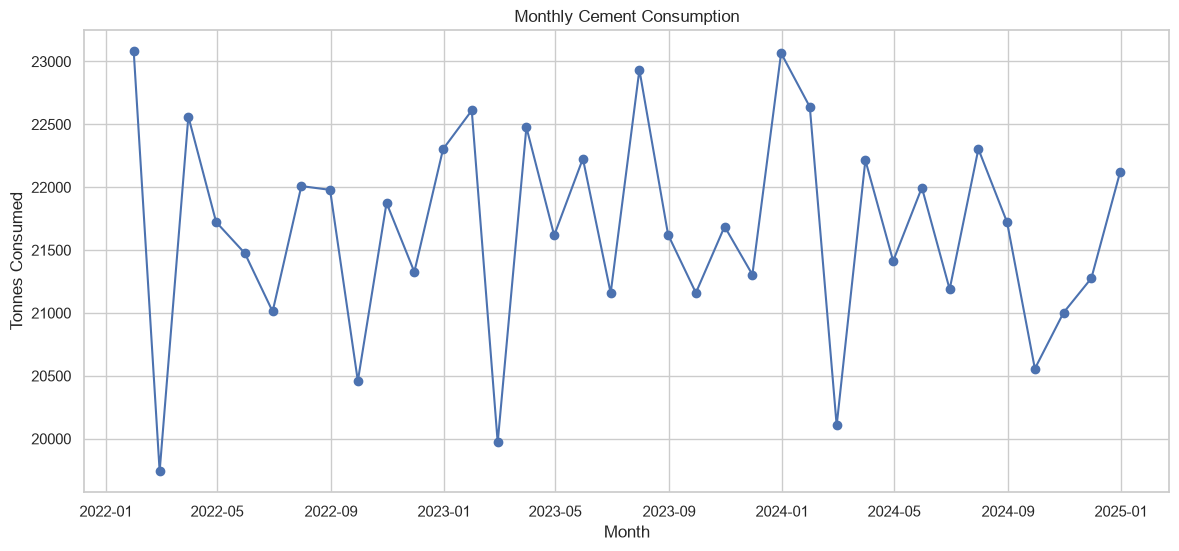

In [ ]:
monthly = df['consumed_tonnes'].resample('M').sum()
plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Cement Consumption")
plt.xlabel("Month")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()


##### Insight: This smooths out daily noise and shows seasonality. With likely spikes at the begining of the year. 

C:\Users\akand\AppData\Local\Temp\ipykernel_24784\1985147188.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df['consumed_tonnes'].resample('Q').sum()


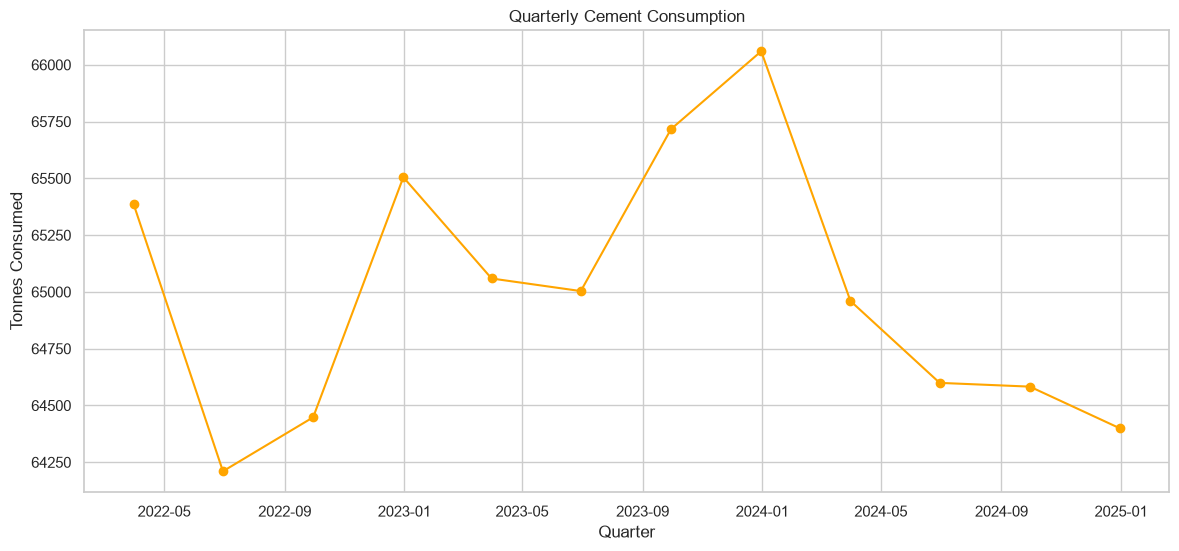

In [ ]:
# Quarterly Cement Consumption.

quarterly = df['consumed_tonnes'].resample('Q').sum()
plt.figure(figsize=(14,6))
plt.plot(quarterly.index, quarterly.values, marker='o', color='orange')
plt.title("Quarterly Cement Consumption")
plt.xlabel("Quarter")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()

### insight: Perfect for business reporting and strategic planning. This shows the cycle of the business. 

C:\Users\akand\AppData\Local\Temp\ipykernel_24784\570664464.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['consumed_tonnes'].resample('Y').sum()


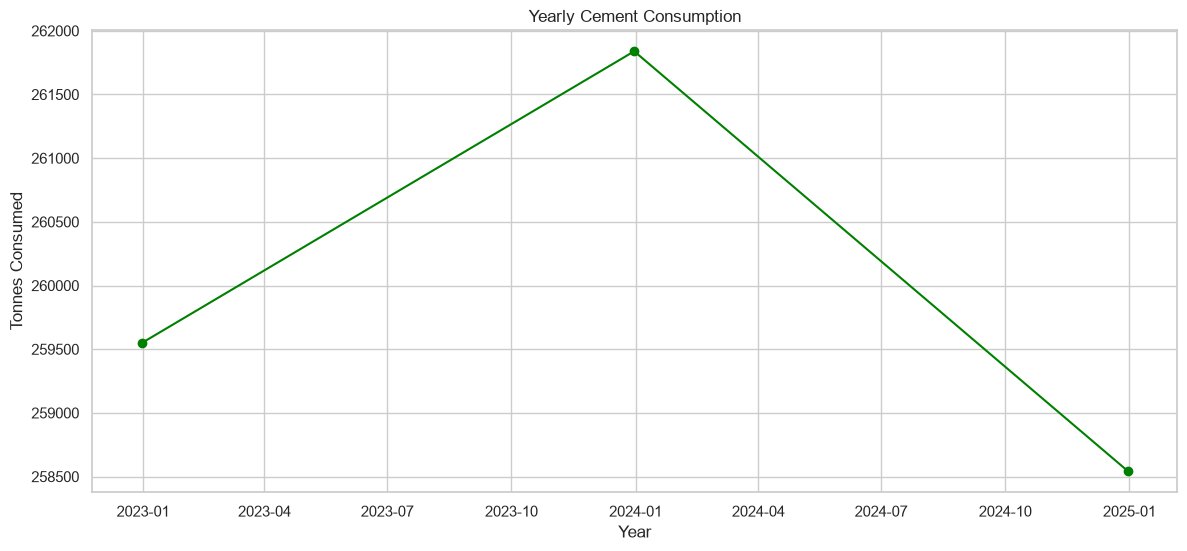

In [ ]:
# Yearly Cement Consumption 

yearly = df['consumed_tonnes'].resample('Y').sum()
plt.figure(figsize=(14,6))
plt.plot(yearly.index, yearly.values, marker='o', color='green')
plt.title("Yearly Cement Consumption")
plt.xlabel("Year")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()

### Insight: This shows long‑term growth or decline. This shows that there was a growth in the year 2024 - structural change. 

c:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\ridewise-venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


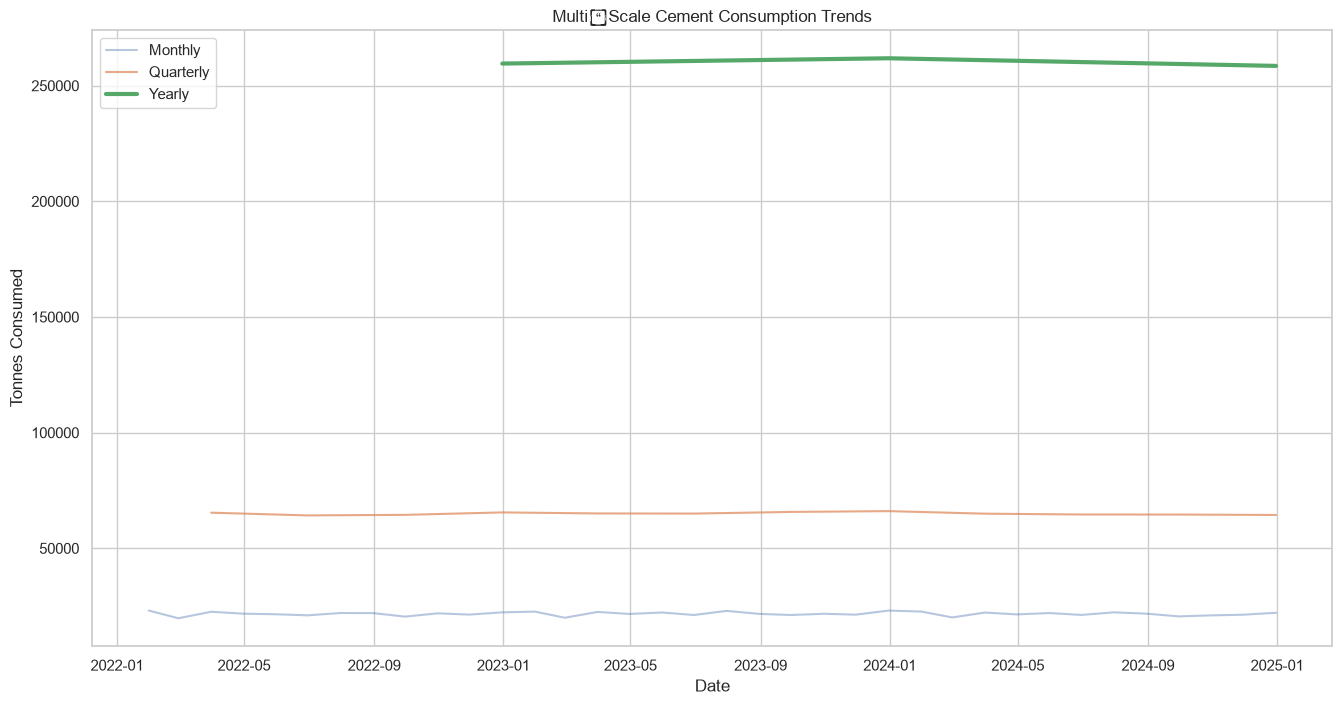

In [ ]:
# A multiscalr comparison.

plt.figure(figsize=(16,8))
plt.plot(monthly.index, monthly.values, alpha=0.4, label='Monthly')
plt.plot(quarterly.index, quarterly.values, alpha=0.7, label='Quarterly')
plt.plot(yearly.index, yearly.values, linewidth=3, label='Yearly')

plt.title("Multi‑Scale Cement Consumption Trends")
plt.xlabel("Date")
plt.ylabel("Tonnes Consumed")
plt.legend()
plt.grid(True)
plt.show()  




### This is a zoom in and zoom out perspective of the trend, seasons and cycle.

##### Daily planned pours

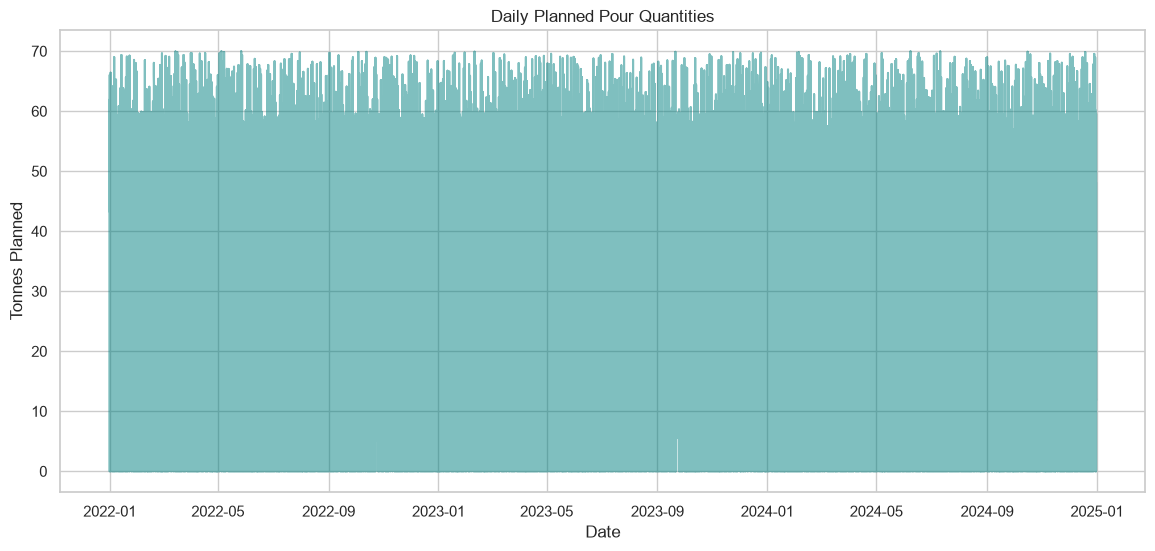

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['planned_pour_tonnes'], alpha=0.5, color='teal')
plt.title("Daily Planned Pour Quantities")
plt.xlabel("Date")
plt.ylabel("Tonnes Planned")
plt.show()

C:\Users\akand\AppData\Local\Temp\ipykernel_24784\65223759.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['planned_pour_tonnes'].resample('M').sum()


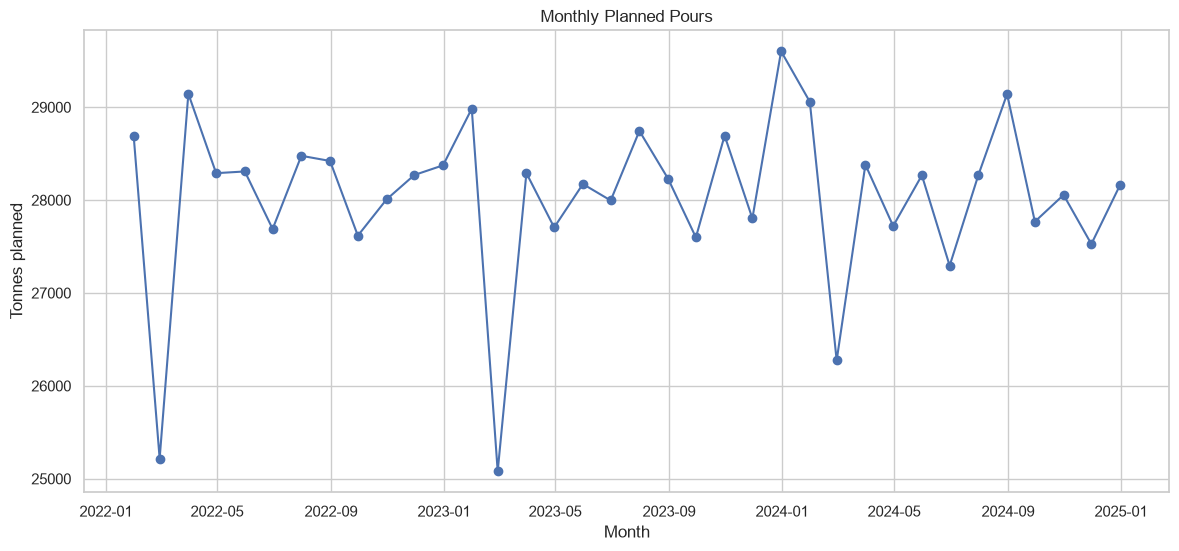

In [ ]:
# Monthly planned pours
monthly = df['planned_pour_tonnes'].resample('M').sum()
plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Planned Pours")
plt.xlabel("Month")
plt.ylabel("Tonnes planned")
plt.grid(True)
plt.show()

##### Insight: There are sharp decline int he months of January - usually at the beginingg of the year. 

C:\Users\akand\AppData\Local\Temp\ipykernel_24784\669031263.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['planned_pour_tonnes'].resample('Y').sum()


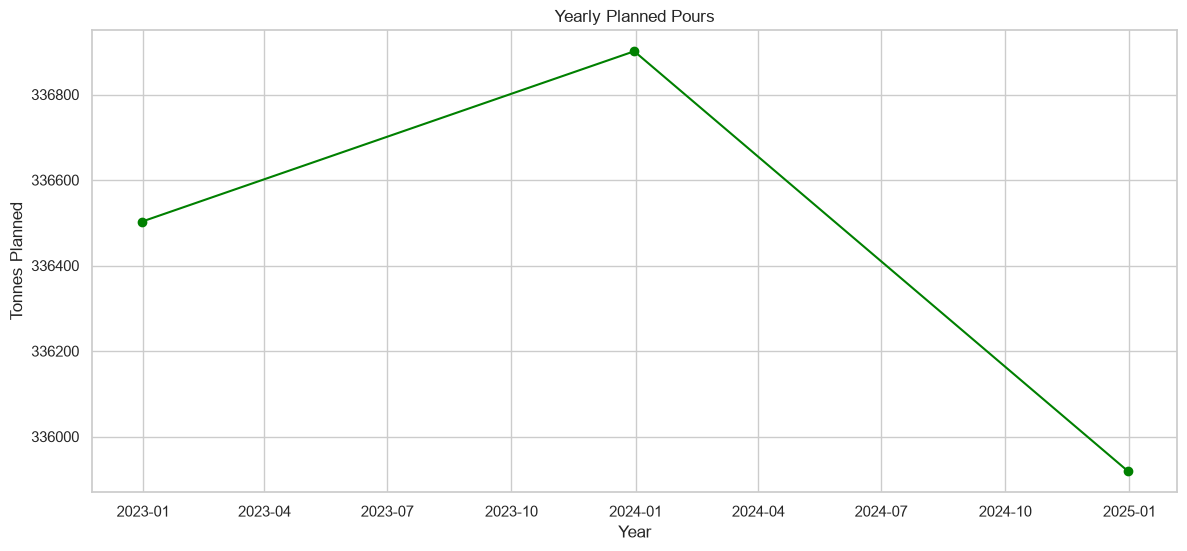

In [ ]:
# Yearly planned pours 

yearly = df['planned_pour_tonnes'].resample('Y').sum()
plt.figure(figsize=(14,6))
plt.plot(yearly.index, yearly.values, marker='o', color='green')
plt.title("Yearly Planned Pours")
plt.xlabel("Year")
plt.ylabel("Tonnes Planned")
plt.grid(True)
plt.show()

##### Year 2024, had the higest number of planned pour

#### Site‑Level EDA

##### Top 15 Sites.

In [ ]:
site_consumption = df.groupby("site_id")["consumed_tonnes"].sum().sort_values(ascending=False)
site_consumption.head(15)

site_id
SITE_025    33604.06
SITE_010    33579.76
SITE_018    33348.09
SITE_001    33056.40
SITE_021    33009.68
SITE_005    32935.68
SITE_022    32934.03
SITE_008    32689.50
SITE_007    32607.65
SITE_011    32587.01
SITE_020    32585.67
SITE_017    32530.14
SITE_003    32520.09
SITE_030    32459.18
SITE_024    29919.14
Name: consumed_tonnes, dtype: float64

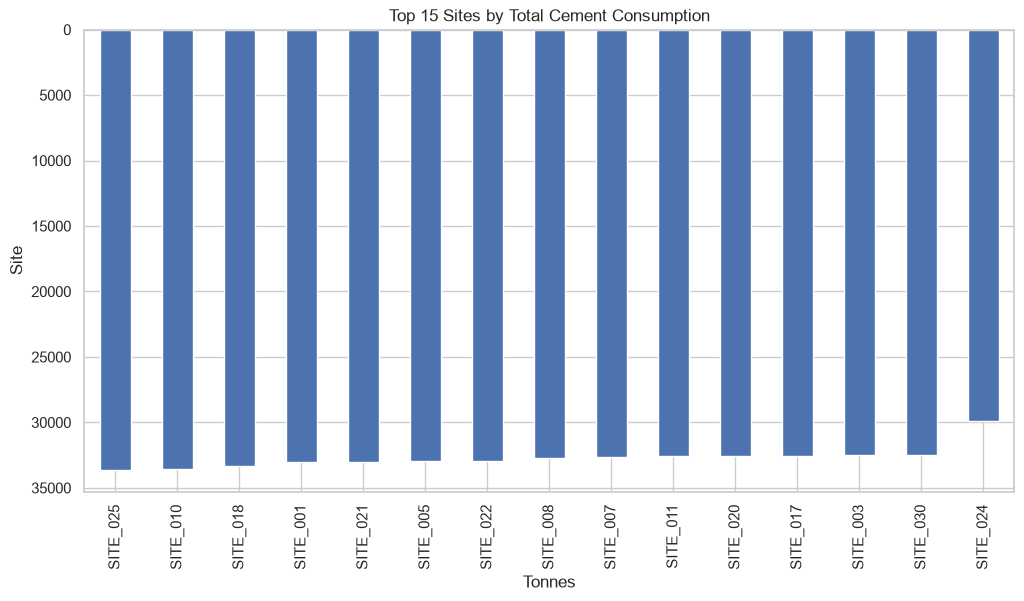

In [96]:
plt.figure(figsize=(12,6))
site_consumption.head(15).plot(kind='bar')  
plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")   # was ylabel before
plt.ylabel("Site")     # was the index before
plt.gca().invert_yaxis() # optional: puts the highest value at the top
plt.show()


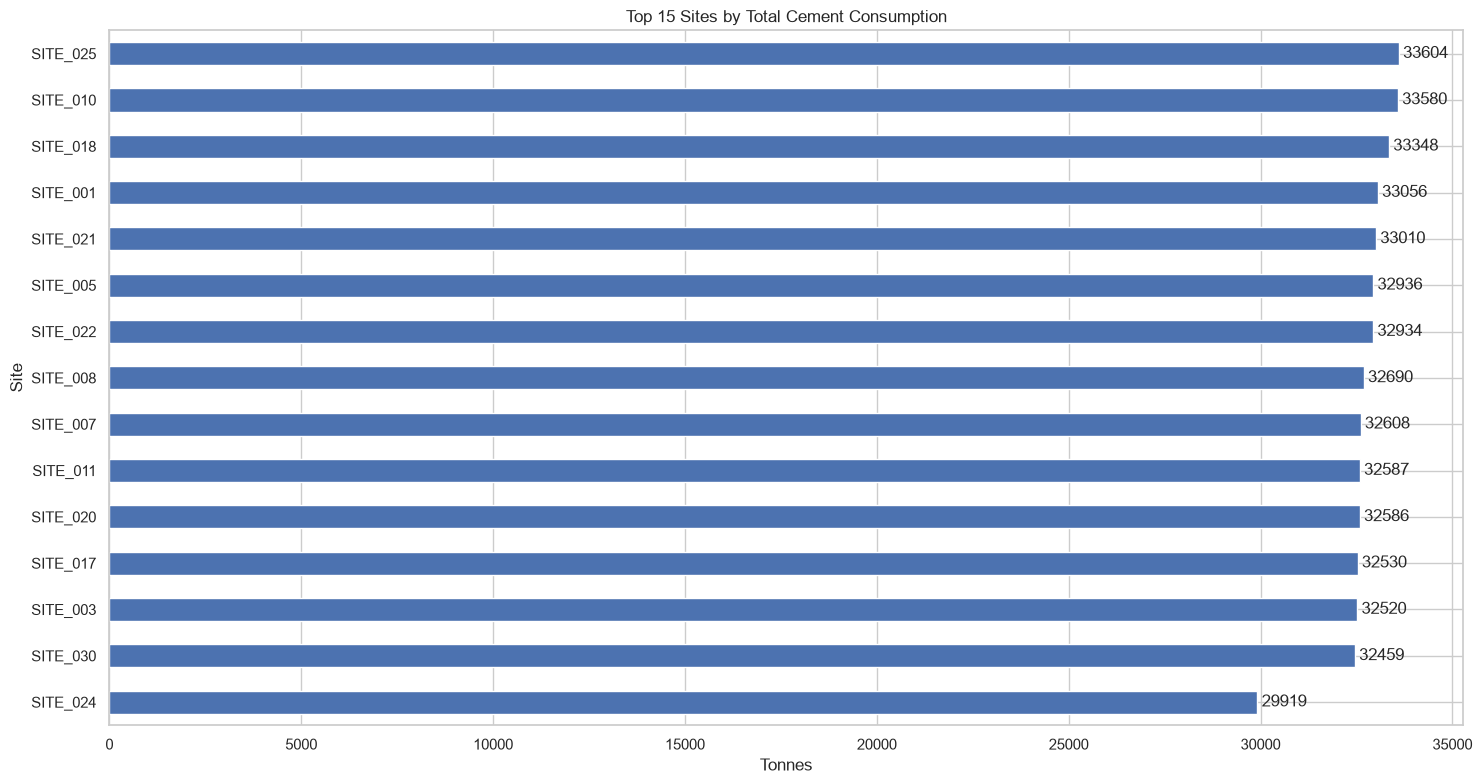

In [ ]:
plt.figure(figsize=(15,8))
ax = site_consumption.head(15).plot(kind='barh')
plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")
ax.invert_yaxis() # biggest on top
# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
# fmt='%.0f' = no decimals. Use '%.1f' if you want 1 decimal
# padding=3 = space between bar end and text
plt.tight_layout()
plt.show()

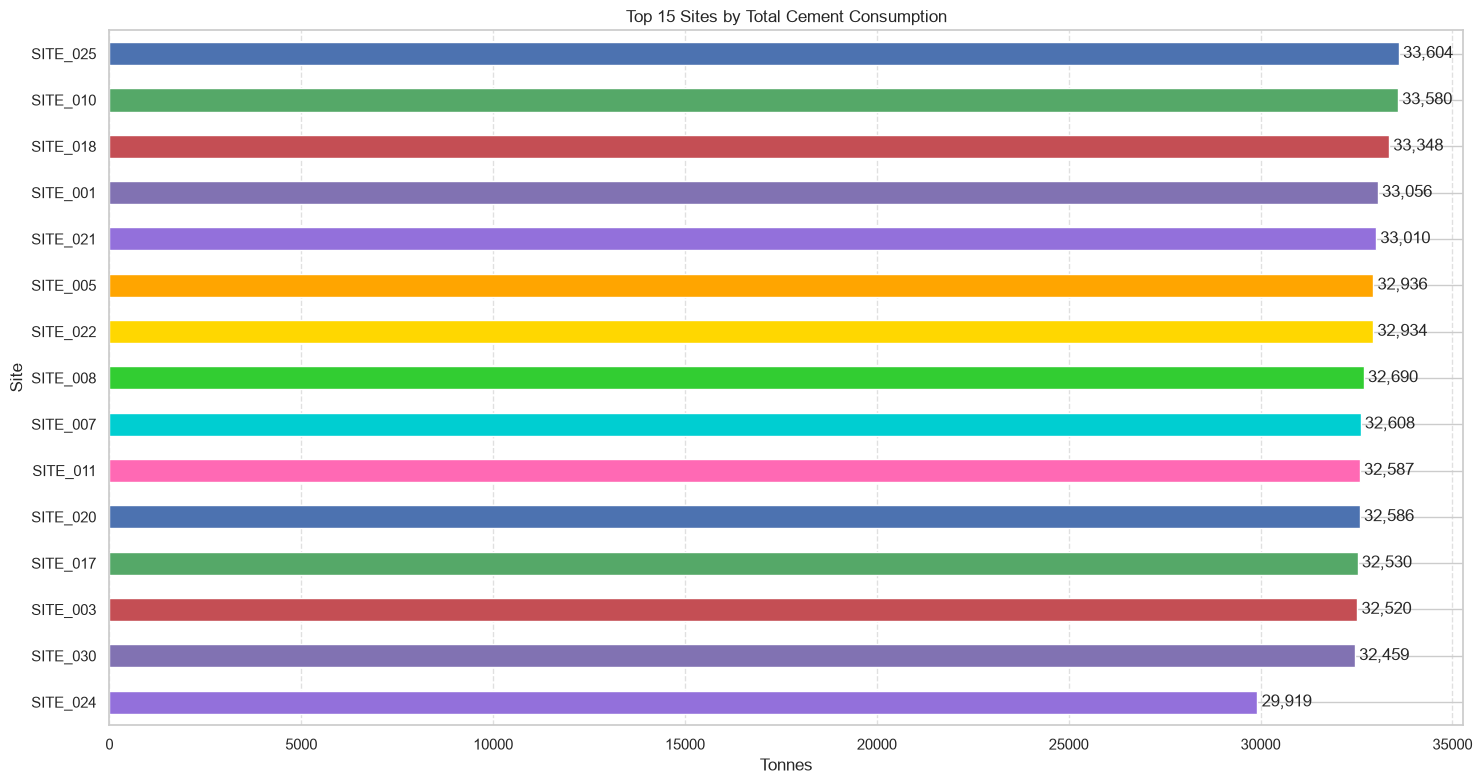

In [ ]:
plt.figure(figsize=(15,8))
ax = site_consumption.head(15).plot(
    kind='barh',
    color=['#4C72B0','#55A868','#C44E54','#8172B2','#9370DB','#FFA500','#FFD700','#32CD32','#00CED1','#FF69B4'] # list of 15 colors, one per bar
)

plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# Add grid lines only on x-axis for easier reading
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3) # {:,.0f} adds commas: 1,245

plt.tight_layout()
plt.show()

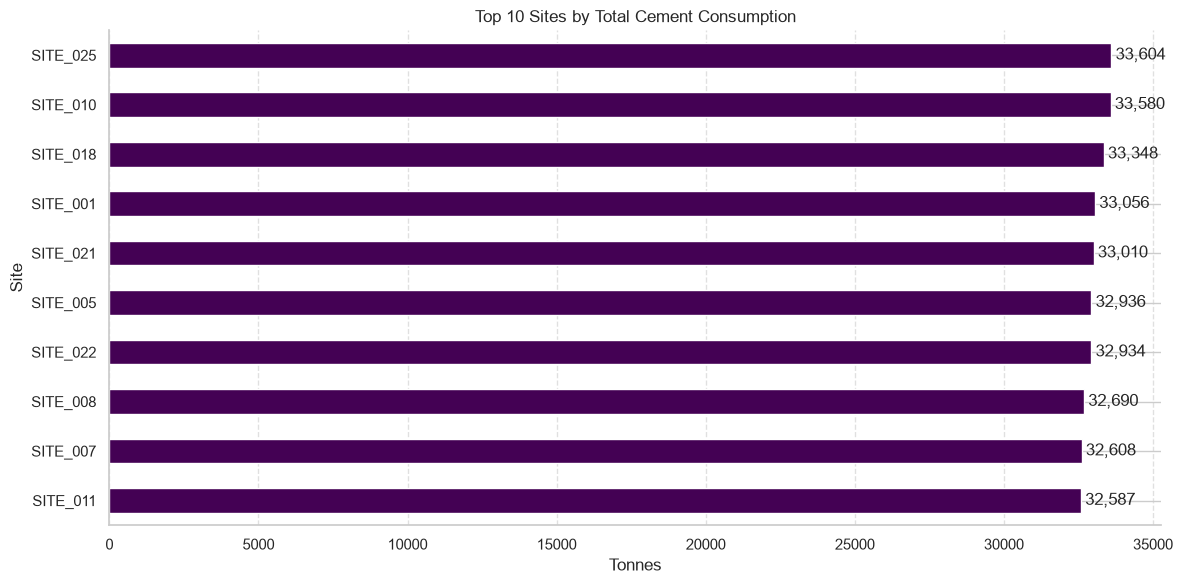

In [ ]:
plt.figure(figsize=(12,6))
ax = site_consumption.head(10).plot(
    kind='barh',
    cmap='viridis' # gradient color map
)

plt.title("Top 10 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# Add grid lines only on x-axis for easier reading
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3) # {:,.0f} adds commas: 1,245

ax.spines['top'].set_visible(False) # remove top border
ax.spines['right'].set_visible(False) # remove right border

plt.tight_layout()
plt.show()

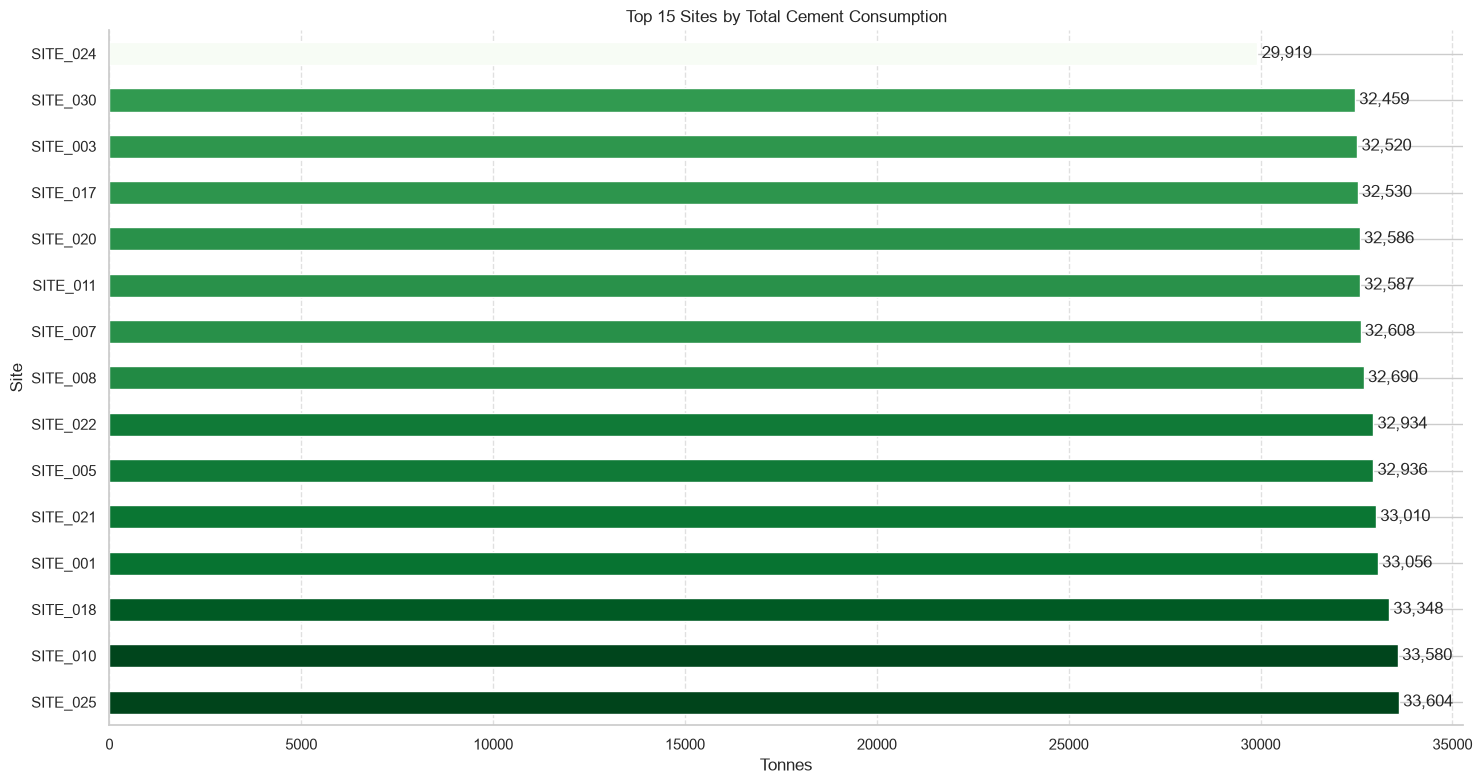

In [ ]:
plt.figure(figsize=(15,8))

# 1. Get top 15 and sort biggest to smallest
data = site_consumption.head(15).sort_values(ascending=True) # ascending=True so biggest ends up on top after invert

# 2. Create a color gradient based on values
norm = plt.Normalize(data.min(), data.max()) # scale values to 0-1
colors = plt.cm.Greens(norm(data)) # Greens colormap. Darkest = highest value
# Other options: 'Reds', 'Greens', 'viridis', 'plasma'

# 3. Plot
ax = data.plot(kind='barh', color=colors)

plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# 4. Grid + labels
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3)

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Region‑level consumption

In [ ]:
region_consumption = df.groupby("region")["consumed_tonnes"].sum()
region_consumption

region
East     318968.12
North     57852.18
South    294887.83
West     108221.08
Name: consumed_tonnes, dtype: float64

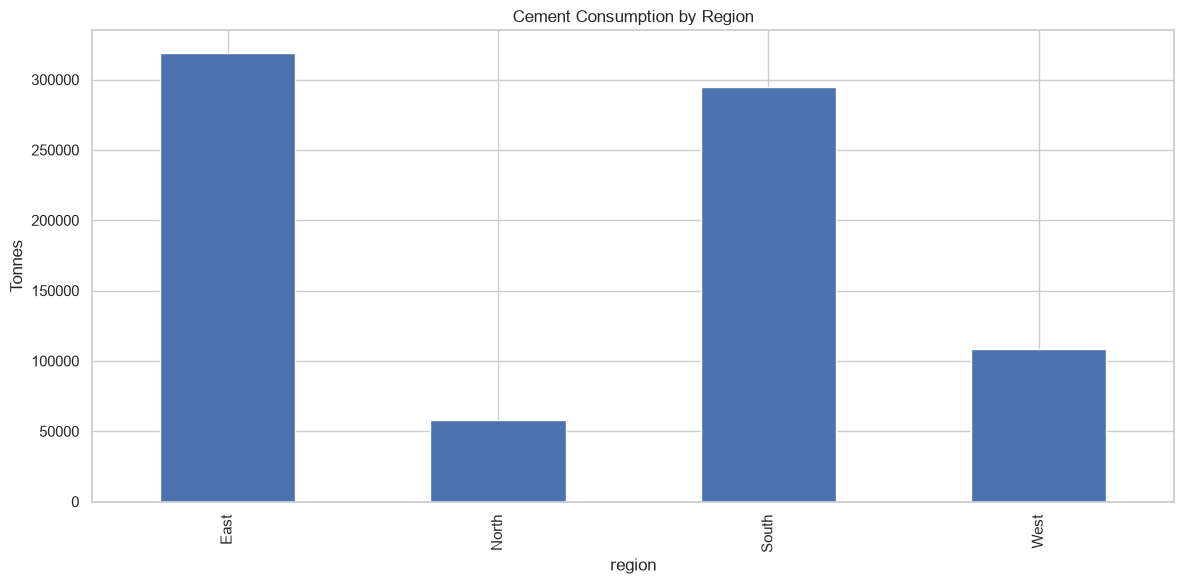

In [ ]:
region_consumption.plot(kind='bar', figsize=(12,6))
plt.title("Cement Consumption by Region")
plt.ylabel("Tonnes")
# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


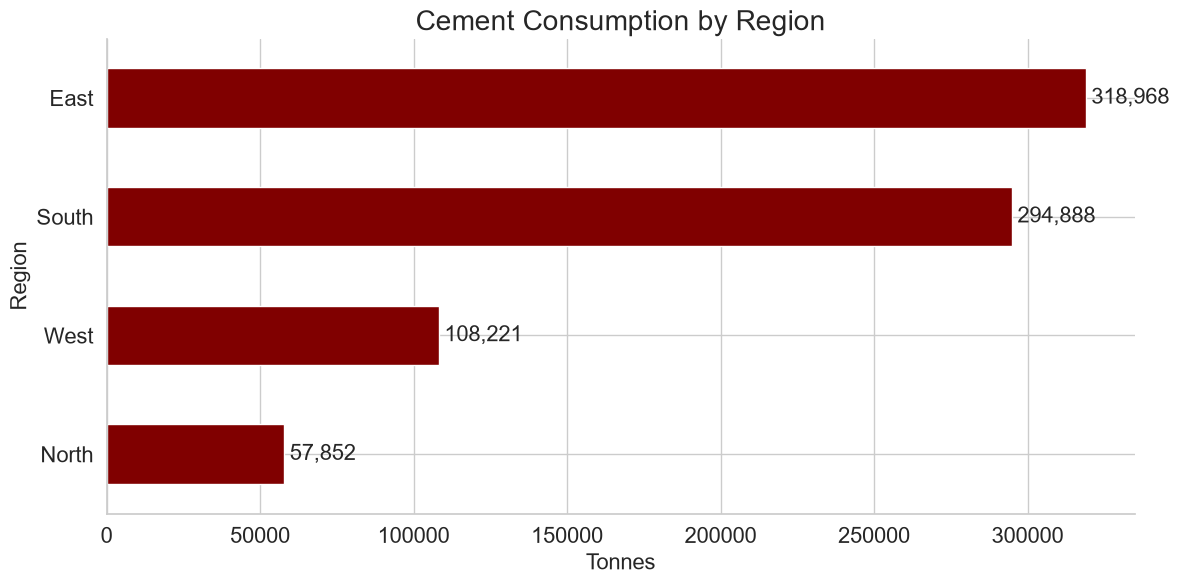

In [ ]:
data = region_consumption.sort_values(ascending=False)

ax = data.plot(kind='barh', figsize=(12,6), color='maroon') # <- barh for horizontal

plt.title("Cement Consumption by Region", fontsize=20) # bigger title
plt.xlabel("Tonnes", fontsize=16)   # was ylabel for vertical bars
plt.ylabel("Region", fontsize=16)   # was index before

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.invert_yaxis() # optional: puts the biggest region on top

# Add value labels at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=16)
plt.tight_layout()
plt.show()

Insight: The EAST region is having more consumption. 

##### Cement Type EDA

In [ ]:
cement_type_usage = df.groupby("cement_type")["consumed_tonnes"].sum()
cement_type_usage

cement_type
CEM_I      259954.71
CEM_II     263418.26
CEM_III    256556.24
Name: consumed_tonnes, dtype: float64

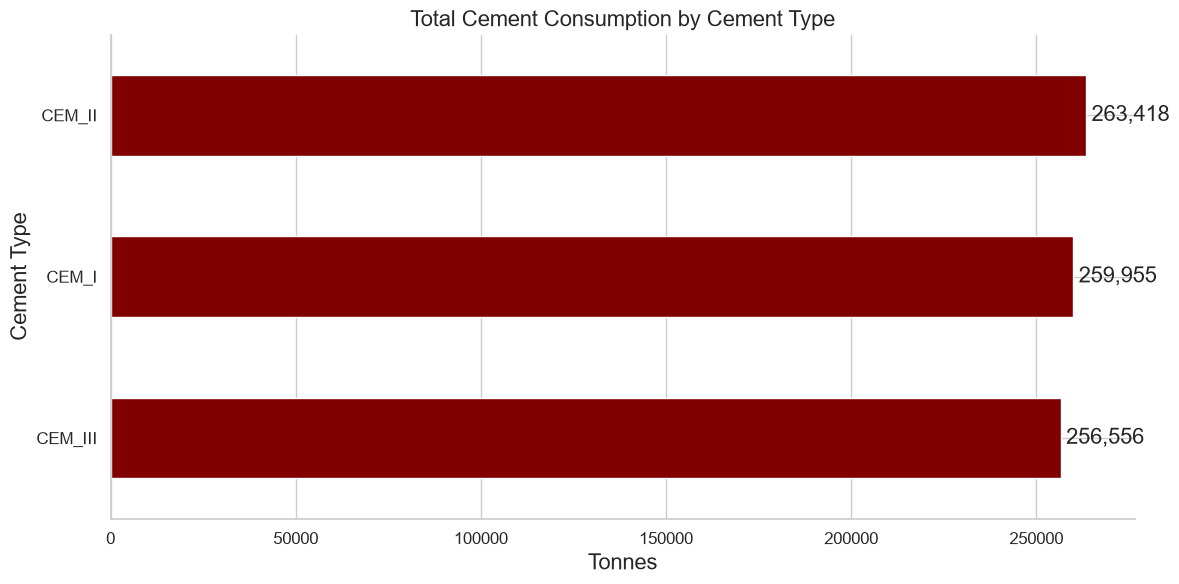

In [ ]:
data = cement_type_usage.sort_values(ascending=False)
ax = data.plot(kind='barh', figsize=(12,6), color='maroon')
plt.title("Total Cement Consumption by Cement Type", fontsize=16)
plt.xlabel("Tonnes", fontsize=16)
plt.ylabel("Cement Type", fontsize=16)

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.invert_yaxis() # optional: puts the biggest cement type on top

ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=16) # add value labels

# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


###### Insight = CEM_II has the hightest consumption rate with a total of 263418.26 consumed tonnes. 

##### Weather Impact EDA

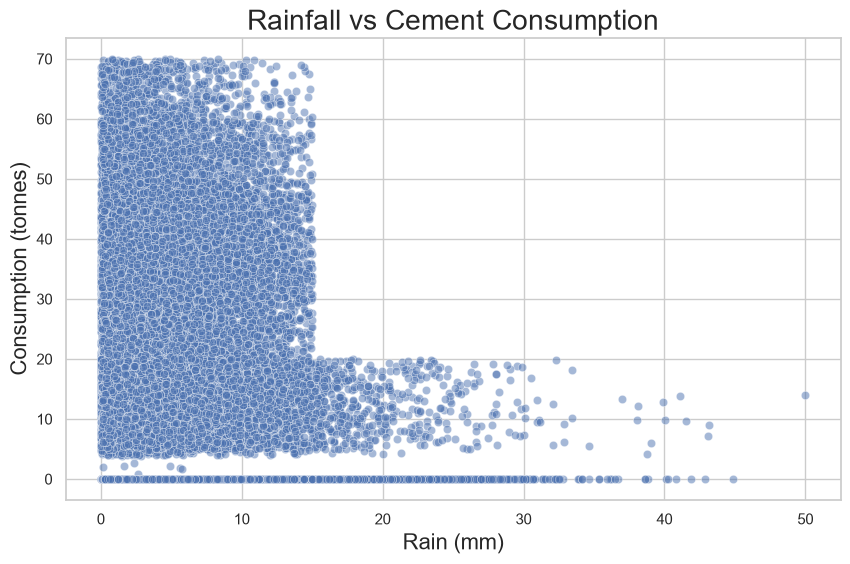

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['rain_mm'], y=df['consumed_tonnes'], alpha=0.5)
plt.title("Rainfall vs Cement Consumption", fontsize=20)
plt.xlabel("Rain (mm)", fontsize=16)
plt.ylabel("Consumption (tonnes)", fontsize=16)
# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


##### Insight:

### Temperature vs Consumption

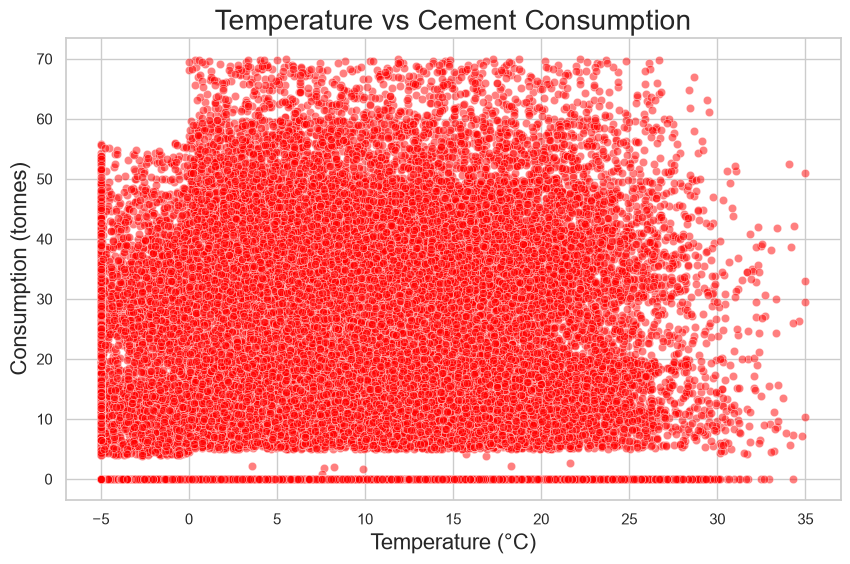

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['avg_temp_c'], y=df['consumed_tonnes'], alpha=0.5, color='red')
plt.title("Temperature vs Cement Consumption", fontsize=20)
plt.xlabel("Temperature (°C)", fontsize=16)
plt.ylabel("Consumption (tonnes)", fontsize=16)
plt.show()


### Insight : Does rain reduce pours? , Does temperature affect consumption?

##### Inventory levels over time

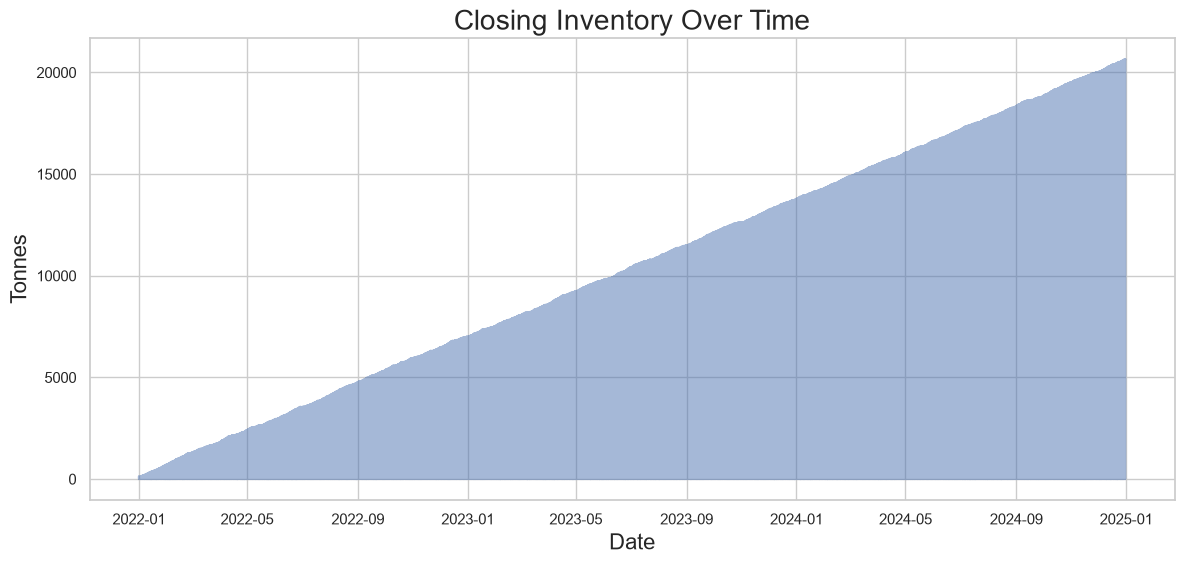

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['closing_inventory_tonnes'], alpha=0.5)
plt.title("Closing Inventory Over Time", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Tonnes", fontsize=16)
plt.show()


##### Insight: Inventory levels over time has increased. 

### Inventory turnover

In [ ]:
df['inventory_turnover'] = df['consumed_tonnes'] / (df['opening_inventory_tonnes'] + 1)

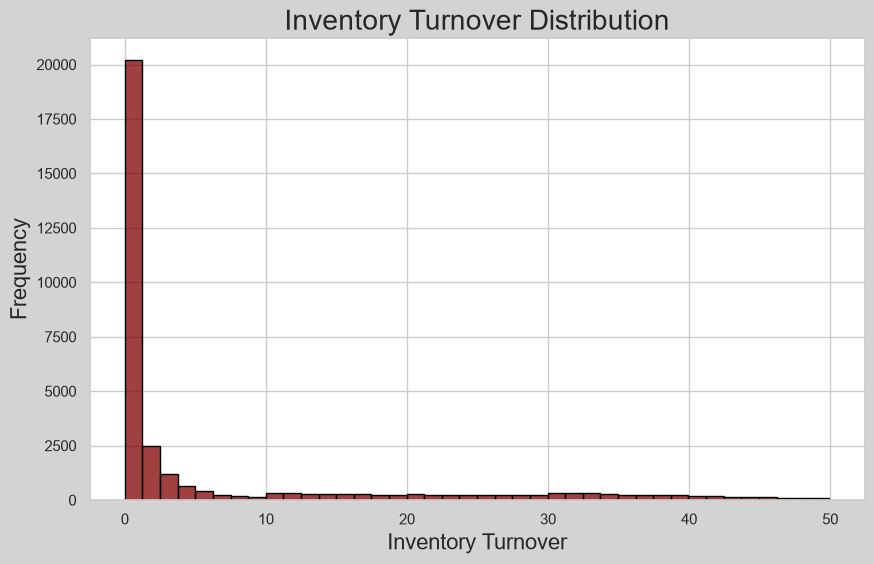

In [99]:
plt.figure(figsize=(10,6), facecolor='lightgray')
sns.histplot(df['inventory_turnover'], bins=40, color='maroon', edgecolor='black')
plt.title("Inventory Turnover Distribution", fontsize=20)
plt.xlabel("Inventory Turnover", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.show()

##### Insight: 

### Correlation Heatmap

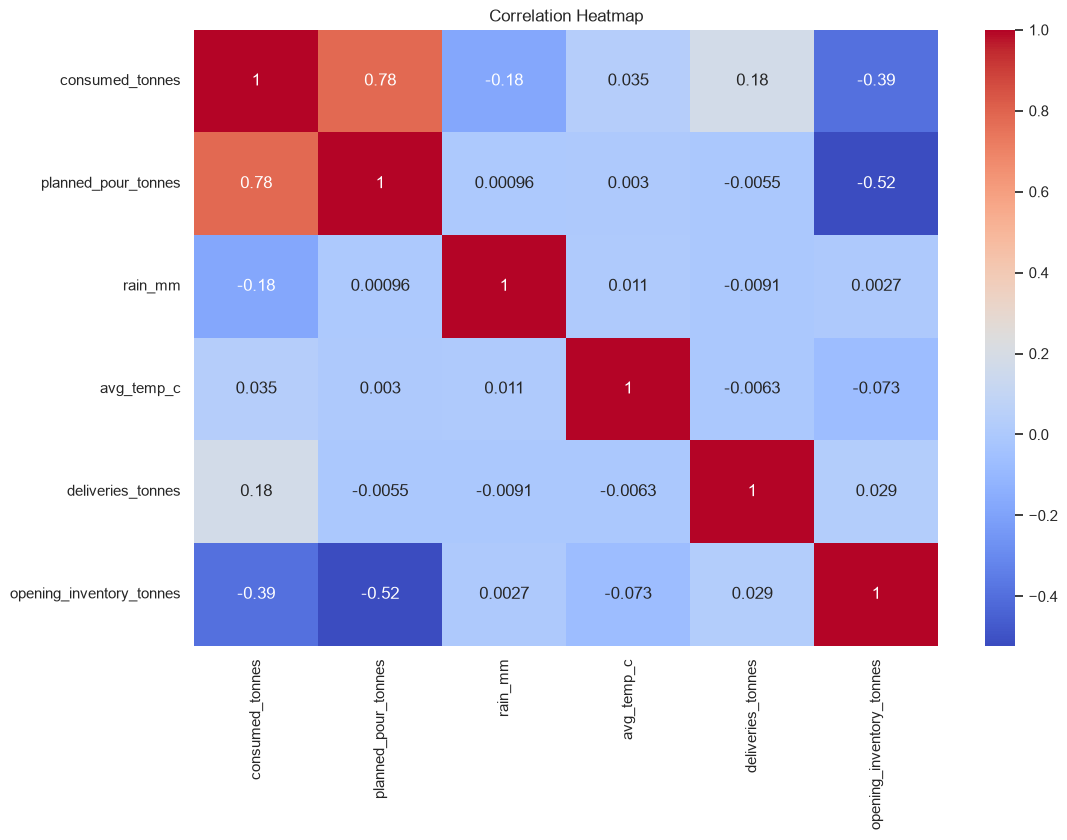

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df[['consumed_tonnes','planned_pour_tonnes','rain_mm','avg_temp_c','deliveries_tonnes','opening_inventory_tonnes']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


###### Insight: There is a correlation between.... 
##### Which variables influence consumption
##### Whether planned pours correlate with actual consumption
##### Whether weather matters

In [97]:
site_consumption.to_csv("site_consumption_summary.csv")
cement_type_usage.to_csv("cement_type_usage_summary.csv")
